Mayah Carlton

# Homework 2

This Notebook will detail Homework 2, which involves a basic capacity expansion model formulation described in [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks)

First, load (or install if necessary) a set of packages you'll need for this assignment...

In [1]:
# Uncomment and run this first line if you need to install or update packages
# import Pkg; Pkg.add("JuMP"); Pkg.add("HiGHS"); Pkg.add("DataFrames"); Pkg.add("CSV")
using JuMP
using HiGHS
using DataFrames
using CSV

### Question 1 - Build the basic thermal generation expansion model

Using the example model in [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks) as your guide, input the code to create a basic thermal generator capacity expansion model, including [downloading the data for Notebook 3 here](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks/expansion_data) and loading the appropriate csv files.

In [2]:
# load the data from Notebook 3
path = joinpath("..","Notebooks", "expansion_data")
generators = CSV.read(joinpath(path, "generators_for_expansion.csv"), DataFrame)
demand = CSV.read(joinpath(path, "demand_for_expansion.csv"), DataFrame)

Row,Hour,Demand
,Int64,Int64
1,1,2274
2,2,2581
3,3,2576
4,4,2482
5,5,2396
6,6,2193
7,7,1929
8,8,1715
9,9,1555


In [3]:
generators

Row,G,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost
,String7,String31,Int64,Int64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Int64,Float64
1,Geo,Geothermal,7500000,130000,0,28.4,0,0.04,30,0.0578,433500,563500,0.0
2,Coal,Supercritical Coal,2600000,120000,8,8.1,2,0.04,30,0.0578,150280,270280,24.2
3,CCGT,Natural gas CCGT,1000000,28000,2,6.4,4,0.035,30,0.0544,54400,82400,27.6
4,CT,Natural gas CT,770000,21000,5,9.7,4,0.035,30,0.0544,41888,62888,43.8
5,Wind,Onshore wind,1000000,40000,0,1.0,0,0.03,30,0.051,51000,91000,0.0
6,Solar,Tracking solar PV,750000,15000,0,1.0,0,0.025,30,0.0478,35850,50850,0.0


In [4]:
NSECost = 9000 # $/MW-year
G = generators.G[1:(size(generators,1)-2)]  # indexing through generators not including wind and solar for now (thermal only)
H = demand.Hour; # indexing through hours

# create the model
Expansion_Model = Model(HiGHS.Optimizer)
# define the decision variables
@variables(Expansion_Model, begin
        CAP[g in G] >=0          # Generating capacity built (MW)
        GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)
# define the constraints
@constraints(Expansion_Model, begin
    cDemandBalance[h in H], sum(GEN[g,h] for g in G) + NSE[h] == demand.Demand[h]
    cCapacity[g in G, h in H], GEN[g,h] <= CAP[g]
end)
# define the objective function
@objective(Expansion_Model, Min,
    sum(generators[generators.G.==g,:FixedCost][1]*CAP[g] + 
        sum(generators[generators.G.==g,:VarCost][1]*GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*NSE[h] for h in H) 
);

Expansion_Model # look at the model


A JuMP Model
├ solver: HiGHS
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 43804
├ num_constraints: 87604
│ ├ AffExpr in MOI.EqualTo{Float64}: 8760
│ ├ AffExpr in MOI.LessThan{Float64}: 35040
│ └ VariableRef in MOI.GreaterThan{Float64}: 43804
└ Names registered in the model
  └ :CAP, :GEN, :NSE, :cCapacity, :cDemandBalance

In [5]:
optimize!(Expansion_Model) # Solve the model

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 43800 rows; 43804 cols; 113880 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 5e+03]
Presolving model
43800 rows, 43804 cols, 113880 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
43800 rows, 43804 cols, 113880 nonzeros  0s
Presolve reductions: rows 43800(-0); columns 43804(-0); nonzeros 113880(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.25679e+07) 0.1s
      27493     9.9087397880e+08 Pr: 0(0) 0.5s

Model status        : Optimal
Simplex   iterations: 27493
Objective value     :  9.9087397880e+08
P-D objectiv

In [6]:
# look at the results
generation = zeros(size(G,1))
for i in 1:size(G,1) 
    generation[i] = sum(value.(GEN)[G[i],:].data) 
end
MWh_share = generation./sum(demand.Demand).*100
cap_share = value.(CAP).data./maximum(demand.Demand).*100
results = DataFrame(
    Resource = G, 
    MW = value.(CAP).data,
    Percent_MW = cap_share,
    GWh = generation/1000,
    Percent_GWh = MWh_share
)
# Calculate how much non-served energy there was and add to results
  # The maximum MW of non-served energy is the difference 
  # between peak demand and total installed generation capacity
NSE_MW = maximum(value.(NSE).data) 
  # The total MWh of non-served energy is the difference between
  # total demand and total generation
NSE_MWh = sum(value.(NSE).data)
  # Add or "push" a new row of data to the end of the results DataFrame
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])

Row,Resource,MW,Percent_MW,GWh,Percent_GWh
,String7,Float64,Float64,Float64,Float64
1,Geo,0.0,0.0,-0.0,-0.0
2,Coal,0.0,0.0,-0.0,-0.0
3,CCGT,3328.0,69.1461,22139.4,98.1011
4,CT,1290.0,26.8024,427.894,1.89603
5,NSE,195.0,4.05153,0.637,0.00282259


## Question 2: Analytical solution

**A.** Using the data provided above, sort the demand data from highest to lowest hours to create a load duration curve and save this as a vector/array/DataFrame of your choice.

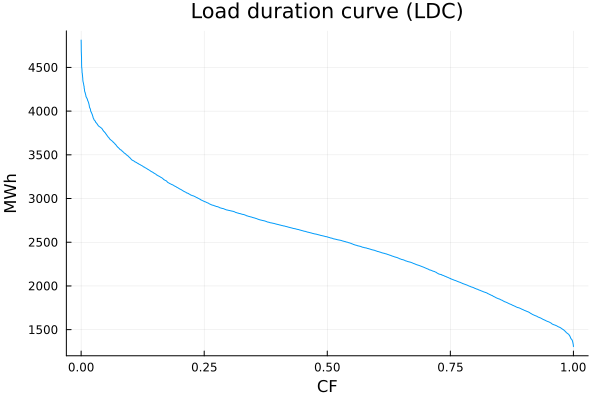

In [7]:
using Plots

# plot the load duration curve sorted in descending order (highest demand to lowest demand)
plot(range(0,1,length=8760), sort(demand.Demand, rev=true), label="")
title!("Load duration curve (LDC)")
xaxis!("CF")
yaxis!("MWh")

**B.** Now using the cost data provided in '/generators_for_expansion.csv' and the load duration curve above, use the formulas provided in Lecture to determine an analytical solution to the optimal thermal generation expansion decisions (e.g. solve it algebraically rather than use an optimization solver to find the solution). 

Report the optimal capacity of each generation source and compare to the solution from the optimization model above. 

Show your work in cells below, using Julia to perform calculations. Explain your steps using inline code comments (e.g. `# Comment`) or by interspersing Markdown cells.  

Tip: round your solutions for the crossover hour between each technology to the nearest integer (as we have discrete hours in the time series).

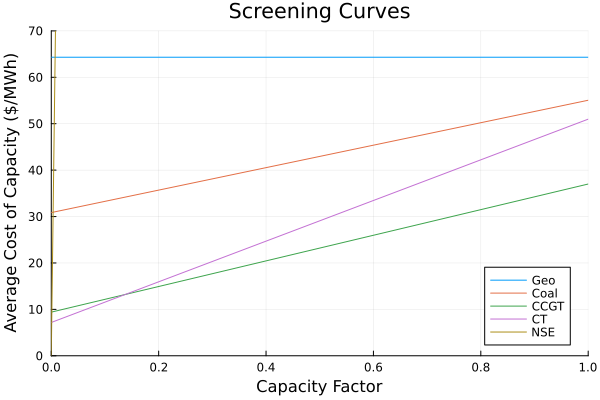

In [8]:
# solve analytically using screening curve

# calculate the screening curve for each generator
cf = range(0,1,length=8760)
plot()  # initialize an empty plot

# loop through each generator and calculate the screening curve, then plot it
for g in G
    fixed_cost = generators[generators.G.==g,:FixedCost][1] # rescale fixed cost
    fixed_cost_normalized = (fixed_cost) ./ 8760  # rescale fixed cost to $/MWh
    var_cost = generators[generators.G.==g,:VarCost][1] # already in $/MWh
    screening_curve = var_cost .* cf .+ fixed_cost_normalized # $/MWh
    plot!(cf, screening_curve, label=string(g))
end

# add NSE to the screening curve plot

screening_NSE = NSECost .* cf
plot!(cf, screening_NSE, label="NSE")

xlims!(0,1)
ylims!(0,70)
title!("Screening Curves")
xaxis!("Capacity Factor")
yaxis!("Average Cost of Capacity (\$/MWh)")


In [9]:
# now I know that the NSE, CT and CCGT are the most price efficient

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CCGT = generators[generators.G.=="CCGT",:FixedCost][1]
var_cost_CCGT = generators[generators.G.=="CCGT",:VarCost][1]
screening_CCGT = var_cost_CCGT .* cf .+ fixed_cost_CCGT ./ 8760

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CT = generators[generators.G.=="CT",:FixedCost][1]
var_cost_CT = generators[generators.G.=="CT",:VarCost][1]
screening_CT = var_cost_CT .* cf .+ fixed_cost_CT ./ 8760

#First intersection of the screening curves is where CT becomes more expensive than CCGT, so we want to find the first index where CT > CCGT
# find the first index and CF where CT > CCGT
idx = 0
for i in 1:length(cf)
    if screening_CT[i] > screening_CCGT[i]
        println("Index: $i, CF: $(cf[i])")
        return idx = i
        break
    end
end

# second intersection of the screening curves is where NSE becomes more efficient than CT, so we want to find the first index where NSE < CT
# find the first index and CF where NSE < CT
idx2 = 0
for i in 1:length(cf)
    if screening_CT[i] < screening_NSE[i]
        println("Index: $i, CF: $(cf[i])")
        return idx2 = i
        break
    end
end

Index: 1206, CF: 0.13757278228108233
Index: 9, CF: 0.0009133462724055258


9

In [10]:
load_duration_curve= sort(demand.Demand, rev=true)

installed_MWh_CCGT = load_duration_curve[idx-1] # this is the load at the intersection of the screening curves
installed_MWh_CT = load_duration_curve[idx2-1] - installed_MWh_CCGT# this is the load at the intersection of the screening curves
NSE_MWh = maximum(load_duration_curve) - installed_MWh_CT - installed_MWh_CCGT  # this is the load at the intersection of the screening curves

println("Installed MWh of CCGT: $installed_MWh_CCGT")
println("Installed MWh of CT: $installed_MWh_CT")
println("NSE MWh: $NSE_MWh")

Installed MWh of CCGT: 3328
Installed MWh of CT: 1290
NSE MWh: 195


Part B: 
From the screening curve, the installed capacity of CCGT and CT are 3328 and 1290 respectively and the NSE is 195. This result matches the optimizer 

**C.** Now change the fuel cost of natural gas to \$8.00/MMBtu, recalculate the variable cost of CCGTs and CTs, and solve again for the optimal generation capacity mix. Describe what changes in your capacity results and what doesn't, and provide an explanation.

In [11]:
# create a copy of the generators DataFrame to modify for the new fuel costs 
new_generators = copy(generators)

# update the fuel costs for CCGT and CT to $8/MWh
new_generators[new_generators.G.=="CCGT",:FuelCost] .= 8.0
new_generators[new_generators.G.=="CT",:FuelCost] .= 8.0

#update the variable costs for CCGT and CT based on the new fuel costs HeatRate*FuelCost + VarOM
new_generators[new_generators.G.=="CCGT",:VarCost] .= new_generators[new_generators.G.=="CCGT",:HeatRate][1]*new_generators[new_generators.G.=="CCGT",:FuelCost][1]+new_generators[new_generators.G.=="CCGT",:VarOM][1]
new_generators[new_generators.G.=="CT",:VarCost] .= new_generators[new_generators.G.=="CT",:HeatRate][1]*new_generators[new_generators.G.=="CT",:FuelCost][1]+new_generators[new_generators.G.=="CT",:VarOM][1]

#check the updated variable costs
new_generators

Row,G,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost
,String7,String31,Int64,Int64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Int64,Float64
1,Geo,Geothermal,7500000,130000,0,28.4,0,0.04,30,0.0578,433500,563500,0.0
2,Coal,Supercritical Coal,2600000,120000,8,8.1,2,0.04,30,0.0578,150280,270280,24.2
3,CCGT,Natural gas CCGT,1000000,28000,2,6.4,8,0.035,30,0.0544,54400,82400,53.2
4,CT,Natural gas CT,770000,21000,5,9.7,8,0.035,30,0.0544,41888,62888,82.6
5,Wind,Onshore wind,1000000,40000,0,1.0,0,0.03,30,0.051,51000,91000,0.0
6,Solar,Tracking solar PV,750000,15000,0,1.0,0,0.025,30,0.0478,35850,50850,0.0


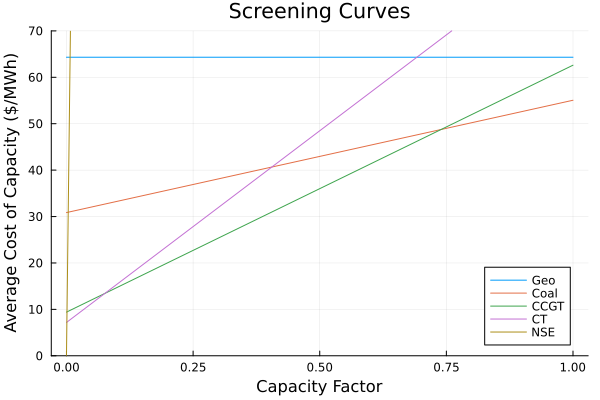

In [12]:
# do the same screening curve analysis with the new variable costs to find the new intersection point and new installed capacity of CCGT and CT
cf = range(0,1,length=8760)
plot()  # Initialize an empty plot

for g in G
    fixed_cost = new_generators[new_generators.G.==g,:FixedCost][1] # rescale fixed cost
    fixed_cost_normalized = (fixed_cost) ./ 8760  # rescale fixed cost to $/MWh
    var_cost = new_generators[new_generators.G.==g,:VarCost][1] # already in $/MWh
    new_screening_curve = var_cost .* cf .+ fixed_cost_normalized # $/MWh
    plot!(cf, new_screening_curve, label=string(g))
end

plot!(cf,screening_NSE, label="NSE")
ylims!(0,70)

title!("Screening Curves")
xaxis!("Capacity Factor")
yaxis!("Average Cost of Capacity (\$/MWh)")

In [13]:
# do the analysis to find the new intersection point of the screening curves for CCGT and CT
# collect the values of the screening curve over the range of CCGT for CT
fixed_cost_CCGT = new_generators[new_generators.G.=="CCGT",:FixedCost][1]
new_var_cost_CCGT = new_generators[new_generators.G.=="CCGT",:VarCost][1]
new_screening_CCGT = new_var_cost_CCGT .* cf .+ fixed_cost_CCGT ./ 8760

# collect the values of the screening curve over the range of CF for CT
fixed_cost_CT = new_generators[new_generators.G.=="CT",:FixedCost][1]
new_var_cost_CT = new_generators[new_generators.G.=="CT",:VarCost][1]
new_screening_CT = new_var_cost_CT .* cf .+ fixed_cost_CT ./ 8760

# find the first index and CF where CT > CCGT
cf_idx = 0
for i in 1:length(cf)
    if new_screening_CT[i] > new_screening_CCGT[i]
        cf_idx = i
        println("Index: $i, CF: $(cf[i])")
        break
    end
end

# find the first index and CF where CCGT > coal
fixed_cost_coal = new_generators[new_generators.G.=="Coal",:FixedCost][1]
new_var_cost_coal = new_generators[new_generators.G.=="Coal",:VarCost][1]
new_screening_coal = new_var_cost_coal .* cf .+ fixed_cost_coal ./ 8760 

cf2_idx = 0
for i in 1:length(cf)
    if new_screening_CCGT[i] > new_screening_coal[i]
        cf2_idx = i
        println("Index: $i, CF: $(cf[i])")
        break
    end
end

# find the first index and CF where NSE < CT
cf_idx3 = 0
for i in 1:length(cf)
    if screening_NSE[i] > new_screening_CT[i]
        cf_idx3 = i
        println("Index: $i, CF: $(cf[i])")
        break
    end
end

load_duration_curve = sort(demand.Demand, rev=true)
new_installed_MWh_coal = load_duration_curve[cf2_idx-1] # this is the load at the intersection of the screening curves
new_installed_MWh_CCGT = load_duration_curve[cf_idx-1] - new_installed_MWh_coal# this is the load at the intersection of the screening curves
new_installed_MWh_CT = load_duration_curve[cf_idx3-1] - new_installed_MWh_CCGT - new_installed_MWh_coal  # this is the load at the intersection of the screening curves
new_NSE_WWh = maximum(load_duration_curve) - new_installed_MWh_CT - new_installed_MWh_CCGT - new_installed_MWh_coal  # this is the load at the intersection of the screening curves
println("Installed MWh of Coal: $new_installed_MWh_coal")
println("Installed MWh of CCGT: $new_installed_MWh_CCGT")
println("Installed MWh of CT: $new_installed_MWh_CT")
println("NSE MWh: $new_NSE_WWh")

Index: 665, CF: 0.07580774060965864
Index: 6479, CF: 0.7395821440803745
Index: 9, CF: 0.0009133462724055258
Installed MWh of Coal: 2110
Installed MWh of CCGT: 1472
Installed MWh of CT: 1036
NSE MWh: 195


In [14]:
# check with optimize solver
NSECost = 9000 # $/MW-year
G = new_generators.G[1:(size(new_generators,1)-2)]  # indexing through generators not including wind and solar for now (thermal only)
H = demand.Hour; # indexing through hours

# create the model
new_Expansion_Model = Model(HiGHS.Optimizer)

# define the decision variables
@variables(new_Expansion_Model, begin
        new_CAP[g in G] >=0          # Generating capacity built (MW)
        new_GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        new_NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)

# define the constraints
@constraints(new_Expansion_Model, begin
    new_cDemandBalance[h in H], sum(new_GEN[g,h] for g in G) + new_NSE[h] == demand.Demand[h]
    new_cCapacity[g in G, h in H], new_GEN[g,h] <= new_CAP[g]
end)

# define the objective function
@objective(new_Expansion_Model, Min,
    sum(new_generators[new_generators.G.==g,:FixedCost][1]*new_CAP[g] + 
        sum(new_generators[new_generators.G.==g,:VarCost][1]*new_GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*new_NSE[h] for h in H) 
);

new_Expansion_Model # look at the model

optimize!(new_Expansion_Model) # solve the model

# look at the results
new_generation = zeros(size(G,1))
for i in 1:size(G,1) 
    new_generation[i] = sum(value.(new_GEN)[G[i],:].data) 
end
MWh_share = new_generation./sum(demand.Demand).*100
cap_share = value.(new_CAP).data./maximum(demand.Demand).*100
results = DataFrame(
    Resource = G, 
    MW = value.(new_CAP).data,
    Percent_MW = cap_share,
    GWh = new_generation/1000,
    Percent_GWh = MWh_share
)
# Calculate how much non-served energy there was and add to results
  # The maximum MW of non-served energy is the difference 
  # between peak demand and total installed generation capacity
NSE_MW = maximum(value.(new_NSE).data) 
  # The total MWh of non-served energy is the difference between
  # total demand and total generation
NSE_MWh = sum(value.(new_NSE).data)
  # Add or "push" a new row of data to the end of the results DataFrame
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 43800 rows; 43804 cols; 113880 nonzeros
Coefficient ranges:
  Matrix  [1e+00, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 5e+03]
Presolving model
43800 rows, 43804 cols, 113880 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
43800 rows, 43804 cols, 113880 nonzeros  0s
Presolve reductions: rows 43800(-0); columns 43804(-0); nonzeros 113880(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(2.25679e+07) 0.2s
      24671     1.4540758470e+09 Pr: 0(0) 0.6s

Model status        : Optimal
Simplex   iterations: 24671
Objective value     :  1.4540758470e+09
P-D objectiv

Row,Resource,MW,Percent_MW,GWh,Percent_GWh
,String7,Float64,Float64,Float64,Float64
1,Geo,0.0,0.0,-0.0,-0.0
2,Coal,2110.0,43.8396,17751.1,78.6565
3,CCGT,1472.0,30.5838,4618.47,20.4648
4,CT,1036.0,21.525,197.67,0.87589
5,NSE,195.0,4.05153,0.637,0.00282259


Part C:
Increasing the price of gas changed the composition of the electricity generation because it made the CCGT and CT plants more expensive to operate than coal. Now coal generation covers a the largest percent of the total followed by CCGT then CT because CCGT is still more economical than CT generation since both were effected by the price change. The solutions to the analytical and solver match.

## Question 3 - Expansion with renewables

**A.** Using JuMP/Julia, implement an optimization model based on the formulation for optimal thermal+renewable capacity expansion provided in Section 2 of [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks). 

In [15]:
# prepare the data for adding renewables to the model
RE_cf = CSV.read(joinpath(path, "wind_solar_for_expansion.csv"), DataFrame)

# get the hourly cf and installed capacity values for wind and solar
wind_cf = RE_cf.Wind
wind_cap = generators[generators.G.=="Wind",:Capex][1]
solar_cf = RE_cf.Solar
solar_cap = generators[generators.G.=="Solar",:Capex][1]
wind_cap

RE_gen = zeros(length(wind_cf)) # initialize an array to store the total generation from wind and solar in each hour

# sum the total generation from wind and solar in each hour based on the capacity factors and installed capacity of each resource
for h in 1:length(wind_cf)
   RE_gen[h] = wind_cf[h] * wind_cap + solar_cf[h] * solar_cap
end

# check that RE_gen now contains the total generation from wind and solar in each hour
RE_gen

8760-element Vector{Float64}:
 359798.97925
  53404.614
  45622.487
  90801.91
 177523.956
 196106.315
 163480.63900000002
 129311.82999999999
 131447.554
 162791.938
 169584.90000000002
 115781.084
  63578.397
      ⋮
  40818.419
 367145.36
 455890.059
 428578.07149999996
 620792.88025
 590557.25475
 670424.5445
 745130.2707499999
 776722.886
 719292.83175
 640327.21875
 517814.51375

In [16]:
#check for loop works to apply the correct constraints for renewable and thermal generators
G = generators.G[1:(size(generators,1))] # indexing through generators now including wind and solar for now (thermal only)
RE = ["Wind", "Solar"] # separate list of renewable generators
for g in G # loop through each generator to check appropriate constraints are applied
  if g in RE
        println("This is a renewable generator, so the generation is less than or equal to the capacity.")
    else
        println("This is a thermal generator, so the generation is less than or equal to the capacity times the capacity factor.")
    end
end
RE_cf

This is a thermal generator, so the generation is less than or equal to the capacity times the capacity factor.
This is a thermal generator, so the generation is less than or equal to the capacity times the capacity factor.
This is a thermal generator, so the generation is less than or equal to the capacity times the capacity factor.
This is a thermal generator, so the generation is less than or equal to the capacity times the capacity factor.
This is a renewable generator, so the generation is less than or equal to the capacity.
This is a renewable generator, so the generation is less than or equal to the capacity.


Row,Hour,Wind,Solar
,Int64,Float64,Float64
1,1,0.0296442,0.440206
2,2,0.0534046,0.0
3,3,0.0456225,0.0
4,4,0.0908019,0.0
5,5,0.177524,0.0
6,6,0.196106,0.0
7,7,0.163481,0.0
8,8,0.129312,0.0
9,9,0.131448,0.0


In [17]:
# create the model with renewables
RE_Expansion_Model = Model(HiGHS.Optimizer)

# define the decision variables (same as before but now including the renewable generators)
@variables(RE_Expansion_Model, begin
        re_CAP[g in G] >=0          # Generating capacity built (MW)
        re_GEN[g in G, h in H] >= 0 # Generation in each hour (MWh)
        re_NSE[h in H] >= 0         # Non-served energy in each hour (MWh)
end)

# demand balance constraint
@constraint(RE_Expansion_Model, [h in H],
    sum(re_GEN[g,h] for g in G) + re_NSE[h] == demand.Demand[h]
)

# capacity constraints separate for renewable and thermal generators
for g in G
    if g in RE
        # renewable constraint: GEN <= CAP * cf
        @constraint(RE_Expansion_Model, [h in H], re_GEN[g, h] <= re_CAP[g] * RE_cf[h, Symbol(g)])
    else
        # thermal constraint: GEN <= CAP
        @constraint(RE_Expansion_Model, [h in H], re_GEN[g, h] <= re_CAP[g])
    end
end

# define the objective function (same as before but now including the renewable generators)
@objective(RE_Expansion_Model, Min,
    sum(generators[generators.G.==g,:FixedCost][1]*re_CAP[g] + 
        sum(generators[generators.G.==g,:VarCost][1]*re_GEN[g,h] for h in H)
    for g in G) + 
    sum(NSECost*re_NSE[h] for h in H) 
);

RE_Expansion_Model # look at the model


A JuMP Model
├ solver: HiGHS
├ objective_sense: MIN_SENSE
│ └ objective_function_type: AffExpr
├ num_variables: 61326
├ num_constraints: 122646
│ ├ AffExpr in MOI.EqualTo{Float64}: 8760
│ ├ AffExpr in MOI.LessThan{Float64}: 52560
│ └ VariableRef in MOI.GreaterThan{Float64}: 61326
└ Names registered in the model
  └ :re_CAP, :re_GEN, :re_NSE

**B.** Solve the model to determine the optimal capacity when wind and solar are available resources and extract results for generation and capacity.

In [18]:
optimize!(RE_Expansion_Model) # solve the model

# look at the results 

RE_generation = zeros(size(G,1))
for i in 1:size(G,1) 
    RE_generation[i] = sum(value.(re_GEN)[G[i],:].data) 
end
MWh_share = RE_generation./sum(demand.Demand).*100
cap_share = value.(re_CAP).data./maximum(demand.Demand).*100
results = DataFrame(
    Resource = G, 
    MW = value.(re_CAP).data,
    Percent_MW = cap_share,
    GWh = RE_generation/1000,
    Percent_GWh = MWh_share
)
# Calculate how much non-served energy there was and add to results
  # The maximum MW of non-served energy is the difference 
  # between peak demand and total installed generation capacity
NSE_MW = maximum(value.(re_NSE).data) 
  # The total MWh of non-served energy is the difference between
  # total demand and total generation
NSE_MWh = sum(value.(re_NSE).data)
  # Add or "push" a new row of data to the end of the results DataFrame
push!(results, ["NSE" NSE_MW NSE_MW/maximum(demand.Demand)*100 NSE_MWh/1000 NSE_MWh/sum(demand.Demand)*100])


Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 61320 rows; 61326 cols; 161976 nonzeros
Coefficient ranges:
  Matrix  [5e-05, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [1e+03, 5e+03]
Presolving model
56856 rows, 56862 cols, 153048 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
56856 rows, 56862 cols, 153048 nonzeros  0s
Presolve reductions: rows 56856(-4464); columns 56862(-4464); nonzeros 153048(-8928) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(6.18517e+06) 0.2s
      40370     8.2899893531e+08 Pr: 0(0); Du: 0(3.09303e-11) 4.3s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex 

Row,Resource,MW,Percent_MW,GWh,Percent_GWh
,String7,Float64,Float64,Float64,Float64
1,Geo,0.0,0.0,0.0,0.0
2,Coal,0.0,0.0,0.0,0.0
3,CCGT,2422.86,50.3398,11367.7,50.3709
4,CT,1419.78,29.4989,453.98,2.01162
5,Wind,349.956,7.27105,1007.7,4.46518
6,Solar,3362.77,69.8684,9738.16,43.1505
7,NSE,136.513,2.83635,0.399328,0.00176945


**C.** What happens to the total firm generation and maximum MW of non-served energy? What does this imply about the capacity value of solar and/or wind built in the optimal capacity mix?

Part C: By adding renewables to the portfolio, CCGT generation and NSE decreased. This is because renewables are able to supplement the baseline load with cheap electricity. However, since renewables are time dependent and not dispatchable, there is still significant reliance on CT to meet peaks in demand where renewables are not contributing. 

## Question 4: Brownfield Expansion Model

**A.** Now implement an optimization model based on the formulation for optimal "brownfield" thermal+renewable capacity expansion (e.g. with existing generators) provided in Section 3 of [Notebook 3](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks).

Use the following data for fixed and variable costs of existing gas capacity. Note: unlike in the formulation in Notebook 3, there is no existing renewable capacity here to consider (only thermal).

In [19]:
# Load new generator options
#path = joinpath([REPLACE THIS WITH PATH TO YOUR power-systems-optimization DIRECTORY HERE],"Notebooks","expansion_data")
path = joinpath("..","Notebooks","expansion_data")
generators = DataFrame(CSV.File(joinpath(path,"generators_for_expansion.csv")))
# Add parameters for existing CCGTs, with the set index "Old"
push!(generators, ["Old_CC" "Existing CCGT" 0 40000 5 7.5 4 0 0 0 0 40000 30])
# Add parameters for existing CTs, with the set index "Old"
push!(generators, ["Old_CT" "Existing CT" 0 30000 11 11.0 4 0 0 0 0 30000 55])

# Set installed capacity for existing CCGTs:
ExistingCap_CCGT = 1260 # Approximate actual existing capacity in SDGE
ExistingCap_CT = 925 # Approximate actual existing capacity in SDGE
# Add new column to generators Data Frame
generators[!,:ExistingCap] = [0,0,0,0,0,0, ExistingCap_CCGT, ExistingCap_CT];
generators # look at the updated generators DataFrame with existing capacity included

Row,G,Description,Capex,FixedOM,VarOM,HeatRate,FuelCost,WACC,AssetLife,CRF,Annuity,FixedCost,VarCost,ExistingCap
,String7,String31,Int64,Int64,Int64,Float64,Int64,Float64,Int64,Float64,Int64,Int64,Float64,Int64
1,Geo,Geothermal,7500000,130000,0,28.4,0,0.04,30,0.0578,433500,563500,0.0,0
2,Coal,Supercritical Coal,2600000,120000,8,8.1,2,0.04,30,0.0578,150280,270280,24.2,0
3,CCGT,Natural gas CCGT,1000000,28000,2,6.4,4,0.035,30,0.0544,54400,82400,27.6,0
4,CT,Natural gas CT,770000,21000,5,9.7,4,0.035,30,0.0544,41888,62888,43.8,0
5,Wind,Onshore wind,1000000,40000,0,1.0,0,0.03,30,0.051,51000,91000,0.0,0
6,Solar,Tracking solar PV,750000,15000,0,1.0,0,0.025,30,0.0478,35850,50850,0.0,0
7,Old_CC,Existing CCGT,0,40000,5,7.5,4,0.0,0,0.0,0,40000,30.0,1260
8,Old_CT,Existing CT,0,30000,11,11.0,4,0.0,0,0.0,0,30000,55.0,925


In [20]:
# define new model
Brownfield_Model = Model(HiGHS.Optimizer)

G = generators.G[1:(size(generators,1))] # indexing through generators now including wind and solar for now (thermal only)
H = demand.Hour; # indexing through hours
RE = ["Wind", "Solar"] # separate list of renewable generators

# new decision variables for brownfield model including new capacity, retired capacity, generation, and non-served energy
@variables(Brownfield_Model, begin
    CAP[g in G] >= 0          # new capacity built (MW)
    RET[g in G] >= 0          # existing capacity retired
    GEN[g in G, h in H] >= 0  # total generation (MWh)
    NSE[h in H] >= 0          # non-served energy (MWh)
end)

# new constraint: existing capacity + new capacity >= generation (can't retire more than existing capacity)
for g in G
    exist_cap = generators[generators.G .== g, :ExistingCap][1]
    @constraint(Brownfield_Model, RET[g] <= exist_cap)
end

# same demand balance constraint but with existing generation from the existing capacity of CCGTs and CTs
@constraint(Brownfield_Model, [h in H],
    sum(GEN[g,h] for g in G) + NSE[h] == demand.Demand[h]
)

# do NOT allow new capacity expansion for old units
for g in G
    if occursin("Old_", g)
        @constraint(Brownfield_Model, CAP[g] == 0)
    end
end

# same generation constraints separated by thermal and renewable with the addition of existing capacity and retired capacity
for g in G
    exist_cap = generators[generators.G .== g, :ExistingCap][1]
    
    # capacity = existing + new - retired
    if g in RE
        @constraint(Brownfield_Model, [h in H], 
            GEN[g, h] <= (exist_cap + CAP[g] - RET[g]) * RE_cf[h, Symbol(g)])
    else
        @constraint(Brownfield_Model, [h in H], 
            GEN[g, h] <= (exist_cap + CAP[g] - RET[g]))
    end
end

@objective(Brownfield_Model, Min,
    sum(
        # cost of NEW construction
        generators[generators.G .== g, :FixedCost][1] * CAP[g] + 
        # cost to keep REMAINING capacity open (FixedOM)
        generators[generators.G .== g, :FixedOM][1] * (generators[generators.G .== g, :ExistingCap][1] - RET[g]) +
        # variable generation costs
        sum(generators[generators.G .== g, :VarCost][1] * GEN[g, h] for h in H)
    for g in G) + 
    sum(NSECost * NSE[h] for h in H) 
)


563500 CAP[Geo] - 130000 RET[Geo] + 270280 CAP[Coal] - 120000 RET[Coal] + 24.2 GEN[Coal,1] + 24.2 GEN[Coal,2] + 24.2 GEN[Coal,3] + 24.2 GEN[Coal,4] + 24.2 GEN[Coal,5] + 24.2 GEN[Coal,6] + 24.2 GEN[Coal,7] + 24.2 GEN[Coal,8] + 24.2 GEN[Coal,9] + 24.2 GEN[Coal,10] + 24.2 GEN[Coal,11] + 24.2 GEN[Coal,12] + 24.2 GEN[Coal,13] + 24.2 GEN[Coal,14] + 24.2 GEN[Coal,15] + 24.2 GEN[Coal,16] + 24.2 GEN[Coal,17] + 24.2 GEN[Coal,18] + 24.2 GEN[Coal,19] + 24.2 GEN[Coal,20] + 24.2 GEN[Coal,21] + 24.2 GEN[Coal,22] + 24.2 GEN[Coal,23] + 24.2 GEN[Coal,24] + 24.2 GEN[Coal,25] + 24.2 GEN[Coal,26] + [[...52516 terms omitted...]] + 9000 NSE[8731] + 9000 NSE[8732] + 9000 NSE[8733] + 9000 NSE[8734] + 9000 NSE[8735] + 9000 NSE[8736] + 9000 NSE[8737] + 9000 NSE[8738] + 9000 NSE[8739] + 9000 NSE[8740] + 9000 NSE[8741] + 9000 NSE[8742] + 9000 NSE[8743] + 9000 NSE[8744] + 9000 NSE[8745] + 9000 NSE[8746] + 9000 NSE[8747] + 9000 NSE[8748] + 9000 NSE[8749] + 9000 NSE[8750] + 9000 NSE[8751] + 9000 NSE[8752] + 9000 NSE[

**B.** Solve the model to determine the optimal capacity when with existing generators and extract results for generation and capacity (including retirements).

In [21]:
optimize!(Brownfield_Model) # solve the model with existing capacity constraints

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 78850 rows; 78856 cols; 280162 nonzeros
Coefficient ranges:
  Matrix  [5e-05, 1e+00]
  Cost    [2e+01, 6e+05]
  Bound   [0e+00, 0e+00]
  RHS     [9e+02, 5e+03]
Presolving model
74376 rows, 74384 cols, 205608 nonzeros  0s
Dependent equations search running on 8760 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.00s (limit = 1000.00s)
74376 rows, 74384 cols, 205608 nonzeros  0s
Presolve reductions: rows 74376(-4474); columns 74384(-4472); nonzeros 205608(-74554) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Ph1: 0(0) 0.3s
      41935     7.3976396423e+08 Pr: 12224(4.0281e+06); Du: 0(6.45796e-08) 5.4s
      46784     7.5494110973e+08 Pr: 0(0); Du: 0(4.29458e-12) 9.4s

Performed postsolve
Solving the original LP from

In [22]:
# extract specific retirement data
retired_MW = [value(RET[g]) for g in G]
new_built_MW = [value(CAP[g]) for g in G]
existing_MW = [generators[generators.G .== g, :ExistingCap][1] for g in G]

# net capacity = existing - retired + new
final_capacity = existing_MW .- retired_MW .+ new_built_MW

results = DataFrame(
    Resource = G,
    Starting_MW = existing_MW,
    Retired_MW = retired_MW,
    New_Built_MW = new_built_MW,
    Final_Total_MW = final_capacity,
    GWh = [sum(value.(GEN[g, :])) / 1000 for g in G]
)

push!(results, ["NSE", 0.0, 0.0, 0.0, NSE_MW, NSE_MWh/1000])

display(results)

Row,Resource,Starting_MW,Retired_MW,New_Built_MW,Final_Total_MW,GWh
,String7,Int64,Float64,Float64,Float64,Float64
1,Geo,0,0.0,0.0,0.0,0.0
2,Coal,0,-0.0,0.0,0.0,0.0
3,CCGT,0,0.0,1417.31,1417.31,8545.01
4,CT,0,0.0,238.555,238.555,105.948
5,Wind,0,0.0,385.045,385.045,1109.3
6,Solar,0,0.0,3357.62,3357.62,9720.26
7,Old_CC,1260,0.0,-0.0,1260.0,2973.4
8,Old_CT,925,0.0,-0.0,925.0,113.611
9,NSE,0,0.0,0.0,136.513,0.399328
